## **Libraray and Data Load**

In [8]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Download dataset from Kaggle
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Load dataset
csv_file = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_file)

# Display first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

## **Exploratory Data Analysis**

In [10]:
print("=" * 50)
print("📊 Statistical Summary")
print("=" * 50)

print(df.describe())

📊 Statistical Summary
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00 

In [11]:
print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory        : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates    : {df.duplicated().sum():,}")

class_counts = df["Class"].value_counts()
fraud_pct    = class_counts[1] / len(df) * 100

print(f"\n── Class Distribution ──────────────────")
print(f"  Legitimate : {class_counts[0]:,}  ({100-fraud_pct:.3f}%)")
print(f"  Fraud      : {class_counts[1]:,}    ({fraud_pct:.3f}%)")
print(f"  Ratio      : 1 fraud per {class_counts[0]//class_counts[1]:,} legit txns")

print(f"\n── Amount Stats by Class ───────────────")
print(df.groupby("Class")["Amount"].agg(["mean","median","max"]).rename(index={0:"Legit",1:"Fraud"}))

Shape         : 284,807 rows × 31 columns
Memory        : 70.6 MB
Missing values: 0
Duplicates    : 1,081

── Class Distribution ──────────────────
  Legitimate : 284,315  (99.827%)
  Fraud      : 492    (0.173%)
  Ratio      : 1 fraud per 577 legit txns

── Amount Stats by Class ───────────────
             mean  median       max
Class                              
Legit   88.291022   22.00  25691.16
Fraud  122.211321    9.25   2125.87


In [12]:
df = df.drop_duplicates()
print(f"After removeing duplipation         : {df.duplicated().sum():,}")
print(f"Shape after removeing duplipation   : {df.shape[0]:,} rows × {df.shape[1]} columns")

After removeing duplipation         : 0
Shape after removeing duplipation   : 283,726 rows × 31 columns


## **EDA (class distribution, Amount/Time distributions, correlation heatmap)**

In [13]:
df["Hour"] = (df["Time"] / 3600).astype(int)
df["Time_Period"] = pd.cut(
    df["Hour"],
    bins=[-1, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"]
)

In [14]:
df["Amount_Category"] = pd.cut(
    df["Amount"],
    bins=[-1, 50, 200, 1000, 5000, float("inf")],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large",
        "Extreme"
    ]
)

In [15]:
# Convert class labels
df["Transaction_Type"] = df["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

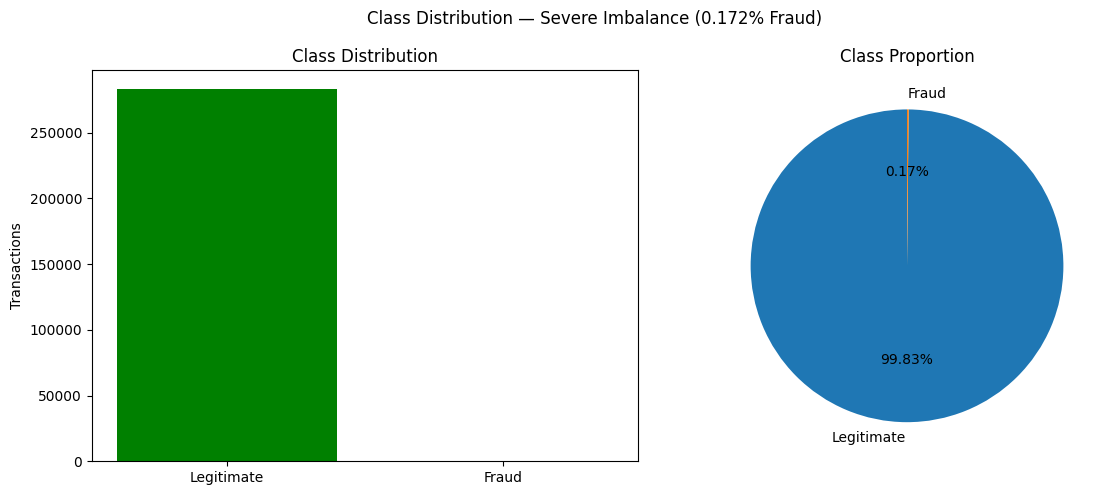

In [16]:
counts = df["Class"].value_counts()

plt.figure(figsize=(12, 5))
plt.suptitle("Class Distribution — Severe Imbalance (0.172% Fraud)")

# Bar Chart
plt.subplot(1, 2, 1)
plt.bar(["Legitimate", "Fraud"], counts, color=["green", "red"])
plt.title("Class Distribution")
plt.ylabel("Transactions")

# Pie Chart
plt.subplot(1, 2, 2)
plt.pie(
    counts,
    labels=["Legitimate", "Fraud"],
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Class Proportion")

plt.tight_layout()
plt.savefig("../visuals/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

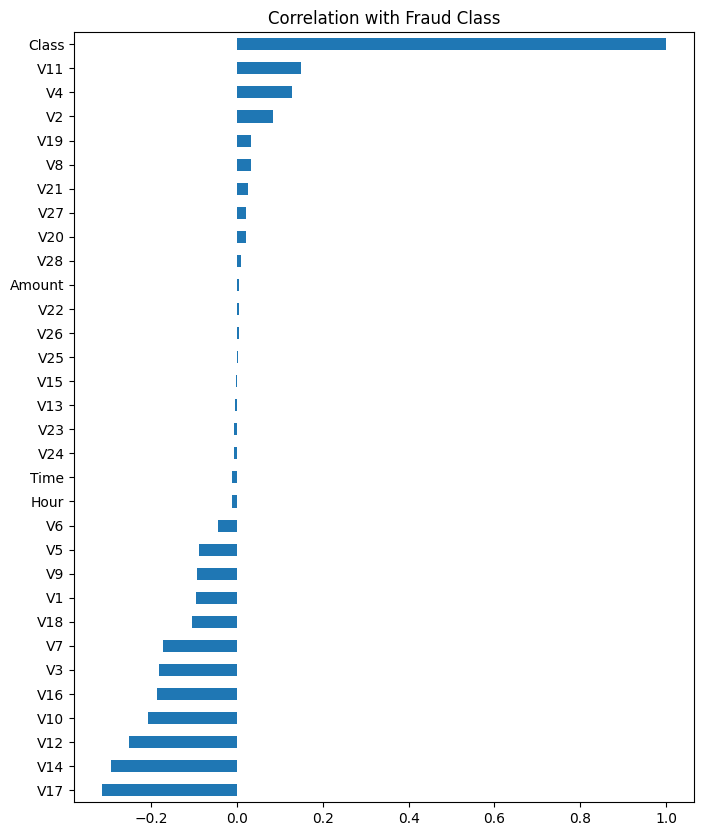

In [17]:
corr = df.corr(numeric_only=True)["Class"].sort_values()

plt.figure(figsize=(8,10))

corr.plot(kind="barh")

plt.title("Correlation with Fraud Class")
plt.savefig("../visuals/feature_correlation_fraud_class.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

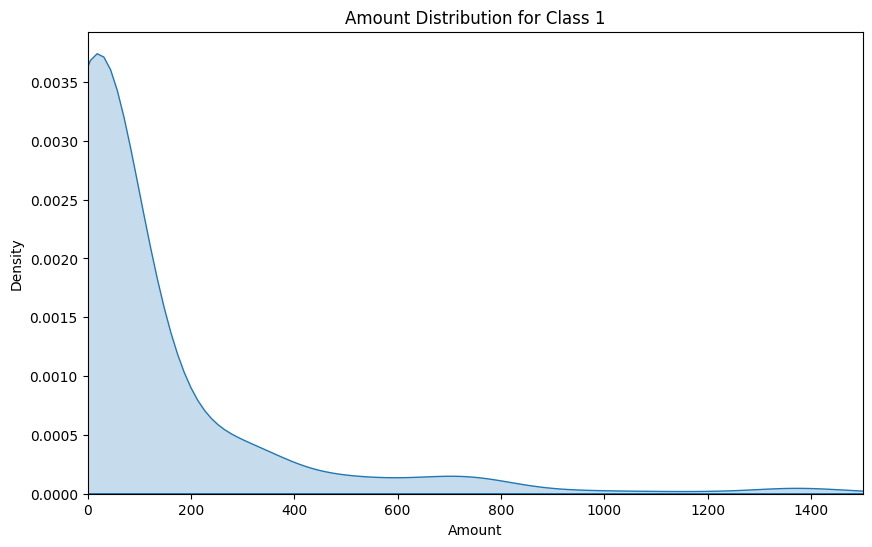

In [18]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df[df["Class"] == 1],
    x="Amount",
    fill=True
)

plt.xlim(0, 1500)
plt.title("Amount Distribution for Class 1")
plt.savefig("../visuals/kde ammount distribution for fraud.png", dpi=300, bbox_inches="tight")
plt.show()

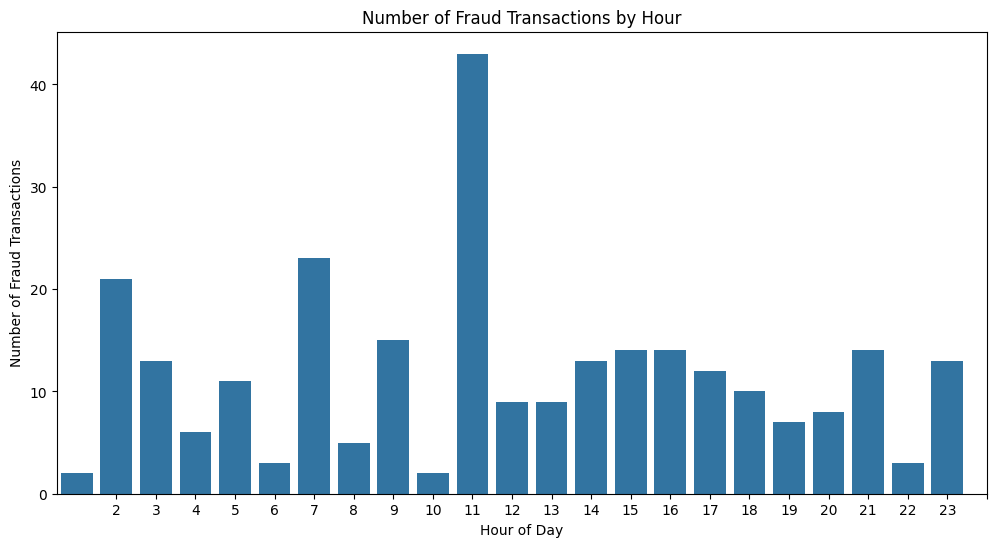

In [20]:
# Keep only fraud transactions
fraud = df[df["Class"] == 1]

# Count fraud transactions per hour
fraud_hour = fraud.groupby("Hour").size()

# Keep hour 1-23 only
fraud_hour = fraud_hour.loc[1:23]

plt.figure(figsize=(12,6))

sns.barplot(
    x=fraud_hour.index,
    y=fraud_hour.values
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraud Transactions")
plt.title("Number of Fraud Transactions by Hour")

plt.xticks(range(1, 24))

# Save figure
plt.savefig(
    "../visuals/fraud_transactions_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

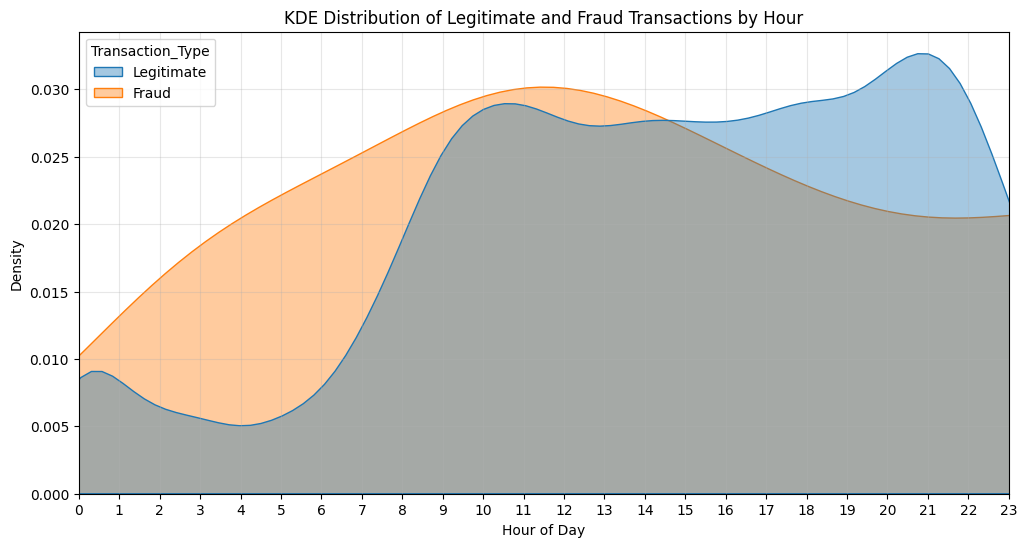

In [ ]:
df["Hour"] = (df["Time"] / 3600).astype(int)

df["Transaction_Type"] = df["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df,
    x="Hour",
    hue="Transaction_Type",
    fill=True,
    common_norm=False,
    bw_adjust=0.8,
    alpha=0.4
)

plt.xticks(range(0,24))
plt.xlim(0,23)

plt.xlabel("Hour of Day")
plt.ylabel("Density")
plt.title("KDE Distribution of Legitimate and Fraud Transactions by Hour")

plt.grid(alpha=0.3)
plt.savefig("../visuals/kde distribution by hour.png", dpi=300, bbox_inches="tight")
plt.show()

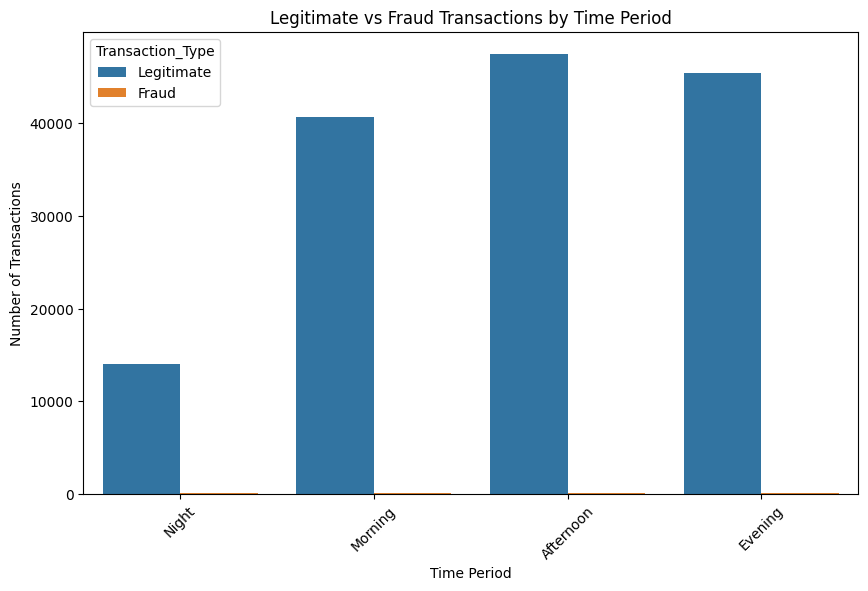

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Time_Period",
    hue="Transaction_Type"
)

plt.xlabel("Time Period")
plt.ylabel("Number of Transactions")
plt.title("Legitimate vs Fraud Transactions by Time Period")

plt.xticks(rotation=45)
plt.savefig("../visuals/Legit vs Fraud by time category.png", dpi=300, bbox_inches="tight")
plt.show()

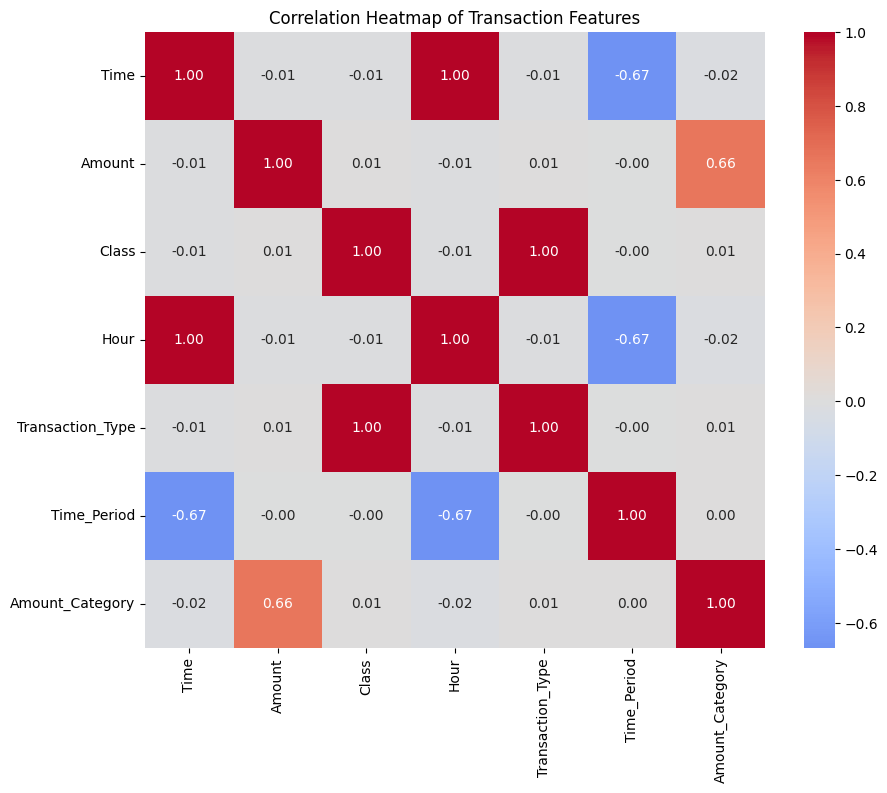

In [ ]:
# Select required columns
corr_df = df[
    [
        "Time",
        "Amount",
        "Class",
        "Hour",
        "Transaction_Type",
        "Time_Period",
        "Amount_Category"
    ]
].copy()

# Convert categorical columns to numeric
corr_df["Transaction_Type"] = corr_df["Transaction_Type"].map({
    "Legitimate": 0,
    "Fraud": 1
})

corr_df["Time_Period"] = corr_df["Time_Period"].astype("category").cat.codes

corr_df["Amount_Category"] = corr_df["Amount_Category"].astype("category").cat.codes


# Correlation matrix
corr = corr_df.corr()

# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Transaction Features")
plt.savefig(
    "../visuals/transaction_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()